##Step 1: Build Graph


In [4]:
%%capture cap
# Check if /content/sample_data exists and remove it
!if [ -d "/content/sample_data" ]; then rm -r /content/sample_data && echo "sample_data deleted."; else echo "sample_data not found."; fi

# Download the main validator script
!wget -O Network_Validator_Main.py https://raw.githubusercontent.com/HanZhengIntelliTransport/GMNS_Plus_Dataset/main/Network_Validator_Main.py

# Download the readiness validator module
!wget -O GMNS_Plus_Readiness_Validator.py https://raw.githubusercontent.com/HanZhengIntelliTransport/GMNS_Plus_Dataset/main/GMNS_Plus_Readiness_Validator.py

# Install micromamba (Conda-lite for Colab)
!curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba

# Create an environment and install ipopt from conda-forge
!./bin/micromamba create -y -n opt_env -c conda-forge ipopt

# Verify ipopt works
!./bin/micromamba run -n opt_env ipopt -v

import os
os.environ["PATH"] = "/root/.local/share/mamba/envs/opt_env/bin:" + os.environ["PATH"]

# Install Accessibility Checking Tool
!pip install DTALite

# Install Pyomo modeling library
!pip install pyomo

# Install GLPK (GNU Linear Programming Kit)
!apt-get install -y glpk-utils

!pip install h3

In [5]:
# Define the network name as a variable
network_name = "17_Sioux_Falls"

# Remove the directory if it already exists
!rm -rf GMNS_Plus_Dataset

# Just clone the entire repository (it's small enough)
!git clone https://github.com/HanZhengIntelliTransport/GMNS_Plus_Dataset.git

# Check what folders exist
!ls -la /content/GMNS_Plus_Dataset/

%cd /content

!mkdir -p GMNS_Tools/Accessibility_checking_tools

!wget -O GMNS_Tools/Accessibility_checking_tools/settings.csv https://raw.githubusercontent.com/HanZhengIntelliTransport/GMNS_Plus_Dataset/main/GMNS_Tools/Accessibility_checking_tools/settings.csv

Cloning into 'GMNS_Plus_Dataset'...
remote: Enumerating objects: 702, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 702 (delta 1), reused 4 (delta 1), pack-reused 697 (from 1)
Receiving objects: 100% (702/702), 678.41 MiB | 17.12 MiB/s, done.
Resolving deltas: 100% (163/163), done.
Updating files: 100% (419/419), done.
total 444
drwxr-xr-x 49 root root   4096 Dec 12 15:55 .
drwxr-xr-x  1 root root   4096 Dec 12 15:54 ..
drwxr-xr-x  6 root root   4096 Dec 12 15:55 01_Bay_Area_MultiModal
drwxr-xr-x  6 root root   4096 Dec 12 15:55 02_King_County_Metropolitan_MultiModal
drwxr-xr-x  6 root root   4096 Dec 12 15:55 03_Phoenix_City_MultiModal
drwxr-xr-x  5 root root   4096 Dec 12 15:55 04_WashingtonDC_City_MultiModal
drwxr-xr-x  3 root root   4096 Dec 12 15:55 05_Anaheim
drwxr-xr-x  3 root root   4096 Dec 12 15:55 06_Berlin-Center
drwxr-xr-x  3 root root   4096 Dec 12 15:55 07_Berlin-Friedrichshain
drwxr-xr-x  3 root root   409

In [6]:
import pandas as pd
import geopandas as gpd
from shapely import wkt, geometry, Polygon
import h3.api.basic_int as h3
import numpy as np

# === CONFIGURATION ===
H3_RESOLUTION = 7
BUFFER_KM = 1
network_path = f"/content/GMNS_Plus_Dataset/{network_name}"
node_file = f"{network_path}/node.csv"
zone_file = f"{network_path}/zone.csv"

# === 1. Load nodes ===
node_df = pd.read_csv(node_file)

# Debug: Check what columns exist
print("Columns in node.csv:", node_df.columns.tolist())
print("\nFirst few rows:")
print(node_df.head())

# Check if we need to create geometry from x_coord and y_coord
if 'geometry' not in node_df.columns:
    if 'x_coord' in node_df.columns and 'y_coord' in node_df.columns:
        print("\nCreating geometry from x_coord and y_coord...")
        node_df["geometry"] = node_df.apply(lambda row: geometry.Point(row['x_coord'], row['y_coord']), axis=1)
    else:
        print("\nError: Cannot find geometry or coordinate columns!")
        print("Available columns:", node_df.columns.tolist())
else:
    node_df["geometry"] = node_df["geometry"].apply(wkt.loads)

node_gdf = gpd.GeoDataFrame(node_df, geometry="geometry", crs="EPSG:4326")

# === 2. Convex hull with buffer ===
convex_hull = node_gdf.geometry.union_all().convex_hull
buffer_degree = BUFFER_KM / 111  # approx conversion
buffered_area = convex_hull.buffer(buffer_degree)
minx, miny, maxx, maxy = buffered_area.bounds

# === 3. Grid scan and fill with H3 ===
step = 0.003  # ~300m
lats = np.arange(miny, maxy, step)
lons = np.arange(minx, maxx, step)

h3_cells = set()
for lat in lats:
    for lon in lons:
        if buffered_area.contains(geometry.Point(lon, lat)):
            h3_id = h3.latlng_to_cell(lat, lon, H3_RESOLUTION)
            h3_cells.add(h3_id)

# === 4. Generate centroid CSV for zones ===
zone_data = []

for h in h3_cells:
    lat, lon = h3.cell_to_latlng(h)
    # Get full H3 hexagon boundary as (lat, lon) list
    boundary_latlon = h3.cell_to_boundary(h)

    # Convert to (lon, lat) for shapely
    boundary_lonlat = [(lng, lat) for lat, lng in boundary_latlon]

    # Create polygon
    hex_polygon = Polygon(boundary_lonlat)

    zone_data.append({
        "zone_id": h,
        "x_coord": lon,
        "y_coord": lat,
        "geometry": geometry.Point(lon, lat).wkt,
        "H3_geometry": hex_polygon.wkt  # Add H3 hexagon as WKT string
    })


zone_df = pd.DataFrame(zone_data)
zone_df.to_csv(zone_file, index=False)
print(f"\nzone.csv saved to: {zone_file}")
print(f"The number of zones is {len(h3_cells)}")

Columns in node.csv: ['name', 'node_id', 'zone_id', 'x_coord', 'y_coord', 'district_id']

First few rows:
   name  node_id  zone_id    x_coord    y_coord  district_id
0   NaN        1        1 -96.770420  43.612828          1.0
1   NaN        2        2 -96.711251  43.605813          2.0
2   NaN        3        3 -96.774303  43.572962          NaN
3   NaN        4        4 -96.747168  43.563654          NaN
4   NaN        5        5 -96.731569  43.564034          NaN

Creating geometry from x_coord and y_coord...

zone.csv saved to: /content/GMNS_Plus_Dataset/17_Sioux_Falls/zone.csv
The number of zones is 35


In [7]:
import pandas as pd
import geopandas as gpd
import folium
from shapely import wkt
from shapely.geometry import Point, Polygon, LineString

# === CONFIGURATION ===
network_path = f"/content/GMNS_Plus_Dataset/{network_name}"

# === LOAD FILES ===
node_df = pd.read_csv(f"{network_path}/node.csv")
link_df = pd.read_csv(f"{network_path}/link.csv")
zone_df = pd.read_csv(f"{network_path}/zone.csv")

# === PARSE NODE GEOMETRY FROM X/Y ===
node_df["geometry"] = node_df.apply(lambda row: Point(row["x_coord"], row["y_coord"]), axis=1)
node_gdf = gpd.GeoDataFrame(node_df, geometry="geometry", crs="EPSG:4326")

# === PARSE ZONE GEOMETRY FROM H3 WKT POLYGONS ===
if "H3_geometry" in zone_df.columns:
    # Parse WKT into shapely Polygons if not already parsed
    if isinstance(zone_df["H3_geometry"].iloc[0], str):
        zone_df["H3_geometry"] = zone_df["H3_geometry"].apply(wkt.loads)

    # Set it as active geometry column
    zone_df["geometry"] = zone_df["H3_geometry"]
    zone_gdf = gpd.GeoDataFrame(zone_df, geometry="geometry", crs="EPSG:4326")
else:
    # Fallback to generic 'geometry' column
    zone_df["geometry"] = zone_df["geometry"].apply(wkt.loads)
    zone_gdf = gpd.GeoDataFrame(zone_df, geometry="geometry", crs="EPSG:4326")

# === PARSE LINK GEOMETRIES FROM WKT ===
if "geometry" in link_df.columns and isinstance(link_df["geometry"].iloc[0], str):
    link_df["geometry"] = link_df["geometry"].apply(wkt.loads)
    link_gdf = gpd.GeoDataFrame(link_df, geometry="geometry", crs="EPSG:4326")
else:
    link_gdf = None

# === INITIALIZE FOLIUM MAP ===
center_lat = node_df["y_coord"].mean()
center_lon = node_df["x_coord"].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="cartodbpositron")

# === DRAW ZONE POLYGONS ===
for _, row in zone_gdf.iterrows():
    geom = row.geometry
    if isinstance(geom, Polygon):
        folium.Polygon(
            locations=[(lat, lon) for lon, lat in geom.exterior.coords],
            color="purple",
            weight=2,
            fill=True,
            fill_opacity=0.3,
            tooltip=f"Zone ID: {row['zone_id']}"
        ).add_to(m)

# === COLOR FUNCTION FOR LINKS ===
def get_color_by_travel_time(time):
    if time < 1:
        return "green"
    elif time < 2:
        return "orange"
    else:
        return "red"

# === DRAW LINKS ===
if link_gdf is not None:
    for _, row in link_gdf.iterrows():
        if isinstance(row.geometry, LineString):
            folium.PolyLine(
                locations=[(lat, lon) for lon, lat in row.geometry.coords],
                color=get_color_by_travel_time(row.get("vdf_fftt", 5)),
                weight=3,
                opacity=0.8,
                popup=f"vdf_fftt: {row.get('vdf_fftt', 'N/A')}"
            ).add_to(m)

# === DRAW NODE MARKERS ===
for _, row in node_df.iterrows():
    folium.CircleMarker(
        location=[row["y_coord"], row["x_coord"]],
        radius=3,
        color="blue",
        fill=True,
        fill_opacity=0.7,
        tooltip=f"Node ID: {row['node_id']}"
    ).add_to(m)

# === DISPLAY INTERACTIVE MAP ===
m

# Step 2: Compute Shortest Path

In [15]:
import pandas as pd
import numpy as np
import random
from pyomo.environ import *

# === CONFIGURATION ===
network_path = f"/content/GMNS_Plus_Dataset/{network_name}"
n_pairs = 3  # Number of random start-end pairs
random_seed = 42

# === READ FILES ===
node_df = pd.read_csv(f"{network_path}/node.csv")
link_df = pd.read_csv(f"{network_path}/link.csv")

# Use vdf_fftt as travel time (free-flow travel time)
if 'vdf_fftt' in link_df.columns:
    link_df['travel_time'] = link_df['vdf_fftt']
else:
    print("Error: No travel time data found!")
    print("Available columns:", link_df.columns.tolist())

# === FILTER NODES WITH ZONE_ID ===
zone_nodes = node_df[node_df['zone_id'].notna()]['node_id'].tolist()

print(f"Found {len(zone_nodes)} nodes with zone_id")

# === SELECT RANDOM START-END PAIRS ===
random.seed(random_seed)
all_pairs = [(i, j) for i in zone_nodes for j in zone_nodes if i != j]
start_end_pairs = random.sample(all_pairs, min(n_pairs, len(all_pairs)))

print(f"Randomly selected start-end pairs: {start_end_pairs}")

# === PREPARE LINK COST DATA ===
link_df = link_df[['from_node_id', 'to_node_id', 'travel_time']].dropna()

# Build cost dictionary c[(i,j)]
c = {}
for _, row in link_df.iterrows():
    c[(int(row['from_node_id']), int(row['to_node_id']))] = float(row['travel_time'])

nodes = sorted(set([i for i, j in c.keys()] + [j for i, j in c.keys()]))
arcs = list(c.keys())

print(f"\nNetwork has {len(nodes)} nodes and {len(arcs)} arcs")

# === BUILD AND SOLVE PYOMO MODEL FOR EACH START-END PAIR ===
for start_node, end_node in start_end_pairs:
    print(f"\n{'='*60}")
    print(f"Solving shortest path from node {start_node} to node {end_node}")
    print(f"{'='*60}")

    model = ConcreteModel()

    model.N = Set(initialize=nodes)
    model.A = Set(within=model.N * model.N, initialize=arcs)

    model.c = Param(model.A, initialize=c)
    model.x = Var(model.A, domain=Binary)
    model.z = Var()

    def obj_rule(m):
        return m.z == sum(m.c[i, j] * m.x[i, j] for (i, j) in m.A)
    model.obj = Constraint(rule=obj_rule)

    def flow_balance_rule(m, n):
        in_flow = sum(m.x[i, n] for (i, n2) in m.A if n2 == n)
        out_flow = sum(m.x[n, j] for (n1, j) in m.A if n1 == n)
        return out_flow - in_flow == (1 if n == start_node else -1 if n == end_node else 0)
    model.flowbal = Constraint(model.N, rule=flow_balance_rule)

    model.OBJ = Objective(expr=model.z, sense=minimize)

    solver = SolverFactory("glpk")
    result = solver.solve(model)

    # Extract solution
    used_arcs = [(i, j) for (i, j) in arcs if model.x[i, j].value == 1]

    # Reconstruct path
    path = []
    current = start_node
    while current != end_node:
        for (i, j) in used_arcs:
            if i == current:
                path.append((i, j))
                current = j
                break

    print(f"Shortest path (ordered): {' → '.join([str(path[0][0])] + [str(j) for i, j in path])}")
    print(f"Total travel time: {model.z.value:.2f} minutes")

Found 24 nodes with zone_id
Randomly selected start-end pairs: [(5, 24), (2, 4), (13, 6)]

Network has 24 nodes and 76 arcs

Solving shortest path from node 5 to node 24
Shortest path (ordered): 5 → 4 → 3 → 12 → 13 → 24
Total travel time: 17.00 minutes

Solving shortest path from node 2 to node 4
Shortest path (ordered): 2 → 6 → 5 → 4
Total travel time: 11.00 minutes

Solving shortest path from node 13 to node 6
Shortest path (ordered): 13 → 12 → 3 → 4 → 5 → 6
Total travel time: 17.00 minutes


In [16]:
def shortest_path(start_node, end_node, link_df, verbose=True):
    """
    Solve single-source shortest path problem using Pyomo.

    Parameters:
    -----------
    start_node : int
        Starting node ID
    end_node : int
        Ending node ID
    link_df : pd.DataFrame
        DataFrame with columns: from_node_id, to_node_id, and travel_time (or vdf_fftt)
    verbose : bool
        Whether to print progress messages

    Returns:
    --------
    tuple: (path, total_travel_time)
        path: list of tuples representing the ordered sequence of arcs [(from, to), ...]
        total_travel_time: float representing total travel time along the path
    """

    # Ensure travel_time column exists
    if 'travel_time' not in link_df.columns:
        if 'vdf_fftt' in link_df.columns:
            link_df = link_df.copy()
            link_df['travel_time'] = link_df['vdf_fftt']
        else:
            raise ValueError("Link dataframe must have 'travel_time' or 'vdf_fftt' column")

    # Prepare link cost data
    link_data = link_df[['from_node_id', 'to_node_id', 'travel_time']].dropna()

    # Build cost dictionary c[(i,j)]
    c = {}
    for _, row in link_data.iterrows():
        c[(int(row['from_node_id']), int(row['to_node_id']))] = float(row['travel_time'])

    nodes = sorted(set([i for i, j in c.keys()] + [j for i, j in c.keys()]))
    arcs = list(c.keys())

    # Build Pyomo model
    model = ConcreteModel()

    model.N = Set(initialize=nodes)
    model.A = Set(within=model.N * model.N, initialize=arcs)

    model.c = Param(model.A, initialize=c)
    model.x = Var(model.A, domain=Binary)
    model.z = Var()

    def obj_rule(m):
        return m.z == sum(m.c[i, j] * m.x[i, j] for (i, j) in m.A)
    model.obj = Constraint(rule=obj_rule)

    def flow_balance_rule(m, n):
        in_flow = sum(m.x[i, n] for (i, n2) in m.A if n2 == n)
        out_flow = sum(m.x[n, j] for (n1, j) in m.A if n1 == n)
        return out_flow - in_flow == (1 if n == start_node else -1 if n == end_node else 0)
    model.flowbal = Constraint(model.N, rule=flow_balance_rule)

    model.OBJ = Objective(expr=model.z, sense=minimize)

    # Solve
    solver = SolverFactory("glpk")
    result = solver.solve(model, tee=False)

    # Extract solution
    used_arcs = [(i, j) for (i, j) in arcs if model.x[i, j].value == 1]

    # Reconstruct ordered path
    path = []
    current = start_node
    while current != end_node:
        for (i, j) in used_arcs:
            if i == current:
                path.append((i, j))
                current = j
                break

    total_travel_time = model.z.value

    if verbose:
        path_str = ' → '.join([str(path[0][0])] + [str(j) for i, j in path])

    return total_travel_time

In [17]:
# === EXAMPLE USAGE ===
# Load the link data
network_path = f"/content/GMNS_Plus_Dataset/{network_name}"
node_df = pd.read_csv(f"{network_path}/node.csv")
link_df = pd.read_csv(f"{network_path}/link.csv")

# Example: Find shortest path between two specific nodes
start = 2
end = 20

travel_time = shortest_path(start, end, link_df, verbose=True)

print(f"\n{'='*60}")
print(f"Result: Path total time {travel_time:.2f}")


Result: Path total time 16.00


# Step 3: Create Request and Vehicle Data Structures

In [1]:
class Request:
    def __init__(self, origin, destination, request_time, latest_pickup, earliest_arrival, id):
        self.origin = origin
        self.destination = destination
        self.trr = request_time            # request time
        self.tplr = latest_pickup          # latest allowed pickup time
        self.t_star = earliest_arrival     # earliest possible dropoff
        self.id = str(id)

    def __repr__(self):
      return f"R{self.id}"


class Vehicle:
    def __init__(self, start_node, start_time, onboard=None, id="vehicle"):
        self.qv = start_node
        self.tv = start_time
        self.Pv = onboard if onboard else []
        self.id = str(id)

    def __repr__(self):
        return f"V{self.id}"


In [2]:
def trip_name(trip_fset):
    req_ids = sorted([r.id for r in trip_fset])
    return "T[" + ",".join(req_ids) + "]"

# Step 4: Run Vehicle Assignment

## Step 4.1: Build Travel Function

Data Types Required:

In [8]:
"""
r.origin      # location
r.destination # location
r.trr         # request time
r.tplr        # latest pickup time
r.t_star      # earliest possible arrival time

vehicle.qv    # current location
vehicle.tv    # current time
vehicle.Pv    # list of passengers already onboard (requests)

route = [
    ("pickup", r1), ("dropoff", r1),
    ("pickup", r2), ("dropoff", r2),
    ...
]
"""

'\nr.origin      # location\nr.destination # location\nr.trr         # request time\nr.tplr        # latest pickup time\nr.t_star      # earliest possible arrival time\n\nvehicle.qv    # current location\nvehicle.tv    # current time\nvehicle.Pv    # list of passengers already onboard (requests)\n\nroute = [\n    ("pickup", r1), ("dropoff", r1),\n    ("pickup", r2), ("dropoff", r2),\n    ...\n]\n'

In [10]:
def violates_constraints(route, vehicle, requests, nu, delta):
  """
  Returns TRUE if ANY constraint is violated.
  Returns FALSE if the route is fully feasible.
  """
  t = vehicle.tv  # vehicle.tv represents current time
  q = vehicle.qv  # vehicle.qv represents current location

  onboard = set(vehicle.Pv) # vehicle.Pv is the list of passengers already on board (requests)
  picked_up = set(vehicle.Pv) # passengers that have already been picked up
  seen_pickup = set(vehicle.Pv) # set precedence

  for action, r in route:
    next_loc = r.origin if action == "pickup" else r.destination
    t += shortest_path(q, next_loc, link_df)
    q = next_loc

    if action == "dropoff" and r not in seen_pickup:
      return True

    if action == "pickup":
      if t > r.tplr:
        return True

      onboard.add(r)
      seen_pickup.add(r)

    elif action == "dropoff":
      if t > r.t_star + delta:
        return True

      onboard.remove(r)

    if len(onboard) > nu:
      return True

  return False


In [11]:
from itertools import permutations

def all_valid_permutations(vehicle, trip_requests):
    """
    Returns all valid pickup-dropoff sequences
    respecting pickup-before-dropoff constraints.
    """
    stops = []

    for p in vehicle.Pv:
      stops.append(("dropoff", p))

    for r in trip_requests:
      stops.append(("pickup", r))
      stops.append(("dropoff", r))

    for perm in permutations(stops):
      ok = True
      picked = set(vehicle.Pv)

      for action, r in perm:
        if action == "pickup":
          picked.add(r)
        else:
          if r not in picked:
            ok = False
            break

      if ok:
        yield perm

In [12]:
def compute_total_delay(route, vehicle):
  """
  Compute the sum of delays for all passengers after executing this route.
  """
  t = vehicle.tv
  q = vehicle.qv

  dropoff_times = {}

  for action, r in route:

    next_loc = r.origin if action == "pickup" else r.destination
    t += shortest_path(q, next_loc, link_df)
    q = next_loc

    if action == "dropoff":
      dropoff_times[r] = t

  total_delay = 0
  for r, tdr in dropoff_times.items():
    total_delay += tdr - r.t_star

  return total_delay



In [13]:
def travel(vehicle, trip_requests, nu=4, delta=300):
    """
    Inputs:
    tau, nu, delta
    Returns:
        None            -> if infeasible
        total_delay     -> if feasible (objective value)
    """

    best_cost = float('inf')
    for route in all_valid_permutations(vehicle, trip_requests):
      if violates_constraints(route, vehicle, trip_requests, nu, delta):
        continue

      cost = compute_total_delay(route, vehicle)

      best_cost = min(best_cost, cost)

    return None if best_cost == float("inf") else best_cost



In [18]:
"""
Test running for travel function
"""

r1 = Request(
    origin=3,
    destination=15,
    request_time=0,
    latest_pickup=300,
    earliest_arrival=shortest_path(3, 15, link_df),
    id = 1
)

r2 = Request(
    origin=10,
    destination=22,
    request_time=20,
    latest_pickup=260,
    earliest_arrival=shortest_path(10, 22, link_df),
    id = 2
)


vehicle = Vehicle(
    start_node=1,
    start_time=0,
    onboard=[]
)

cost_r1 = travel(vehicle, {r1})
print("Cost for trip {r1}:", cost_r1)

Cost for trip {r1}: 4.0


## Step 4.2: Build RTV GRaph

In [19]:
import itertools
import networkx as nx

RTV = nx.DiGraph()

# Store all trips: key is frozenset({r1, r2, ...}), value is trip object
TRIPS = {}

# Helper to canonicalize trip as a hashable object
def trip_key(req_set):
    return frozenset(req_set)


In [20]:
def build_RV_graph(requests, vehicles):
    RV = set()   # (r, v) pairs

    for r in requests:
        for v in vehicles:
            cost = travel(v, {r})
            if cost is not None:
                RV.add((r, v))
    return RV


In [21]:
def build_trips(requests, vehicles, RV, max_capacity=4):
    all_trips = {}

    # For each vehicle separately (as in the paper)
    for v in vehicles:

        Tk = {1: []}  # Tk[k] = feasible trips of size k for vehicle v

        # --------------------------------------
        # 1) Trips of size 1
        # --------------------------------------
        for r in requests:
            if (r, v) not in RV:
                continue
            cost = travel(v, {r})
            if cost is not None:
                tk = trip_key({r})
                Tk[1].append((tk, {r}, cost))

                RTV.add_node(tk)
                RTV.add_node(v)
                RTV.add_edge(r, tk)   # R → T
                RTV.add_edge(tk, v)   # T → V

                all_trips[tk] = {r}

        # --------------------------------------
        # 2) Trips of size 2
        # --------------------------------------
        Tk[2] = []
        for (tk1, tset1, _) in Tk[1]:
            for (tk2, tset2, _) in Tk[1]:
                r1 = next(iter(tset1))
                r2 = next(iter(tset2))
                if r1 == r2:
                    continue

                # pairwise feasibility: both requests individually link to v
                if (r1, v) not in RV or (r2, v) not in RV:
                    continue

                trip = {r1, r2}
                cost = travel(v, trip)

                if cost is None:
                    continue

                tkey = trip_key(trip)
                Tk[2].append((tkey, trip, cost))

                RTV.add_node(tkey)
                RTV.add_edge(r1, tkey)
                RTV.add_edge(r2, tkey)
                RTV.add_edge(tkey, v)

                all_trips[tkey] = trip

        # --------------------------------------
        # 3) Trips of size k >= 3
        # --------------------------------------
        for k in range(3, max_capacity + 1):
            Tk[k] = []
            for (_, t1, _) in Tk[k-1]:
                for (_, t2, _) in Tk[k-1]:
                    union = t1 | t2
                    if len(union) != k:
                        continue

                    # Check that all (k-1)-subsets are feasible trips
                    all_subsets_ok = True
                    for r in union:
                        subset_key = trip_key(union - {r})
                        if subset_key not in all_trips:
                            all_subsets_ok = False
                            break

                    if not all_subsets_ok:
                        continue

                    # Check full trip feasibility
                    cost = travel(v, union)
                    if cost is None:
                        continue

                    tkey = trip_key(union)
                    Tk[k].append((tkey, union, cost))

                    for r in union:
                        RTV.add_edge(r, tkey)

                    RTV.add_edge(tkey, v)
                    all_trips[tkey] = union

    return all_trips


In [22]:
"""
Test RTV Graph
"""
r1 = Request(
    origin=3,
    destination=15,
    request_time=0,
    latest_pickup=300,
    earliest_arrival=shortest_path(3, 15, link_df),
    id = 1
)

r2 = Request(
    origin=10,
    destination=22,
    request_time=20,
    latest_pickup=260,
    earliest_arrival=shortest_path(10, 22, link_df),
    id = 2
)

r3 = Request(
    origin=23,
    destination = 12,
    request_time = 5,
    latest_pickup = 200,
    earliest_arrival = shortest_path(23, 12, link_df),
    id = 3
)

requests = [r1, r2, r3]

v1 = Vehicle(
    start_node=1,
    start_time=0,
    onboard=[],
    id = 1
)

v2 = Vehicle(start_node=8, start_time=0, onboard=[], id="v2")

vehicles = [v1, v2]

RV = set()

for r in requests:
    for v in vehicles:
        if travel(v, {r}) is not None:
            RV.add((r, v))


In [ ]:
"""
Run RTV Graph
"""

import networkx as nx
RTV = nx.DiGraph()

TRIPS = build_trips(requests, vehicles, RV, max_capacity=4)


Streaming output truncated to the last 5000 lines.
Path: 23 → 14 → 11 → 10
Total travel time: 13.00 minutes
Solving shortest path from node 10 to node 3
Path: 10 → 9 → 5 → 4 → 3
Total travel time: 14.00 minutes
Solving shortest path from node 3 to node 15
Path: 3 → 4 → 11 → 14 → 15
Total travel time: 19.00 minutes
Solving shortest path from node 15 to node 12
Path: 15 → 14 → 11 → 12
Total travel time: 15.00 minutes
Solving shortest path from node 12 to node 22
Path: 12 → 13 → 24 → 21 → 22
Total travel time: 12.00 minutes
Solving shortest path from node 8 to node 23
Path: 8 → 7 → 18 → 20 → 22 → 23
Total travel time: 18.00 minutes
Solving shortest path from node 23 to node 10
Path: 23 → 14 → 11 → 10
Total travel time: 13.00 minutes
Solving shortest path from node 10 to node 3
Path: 10 → 9 → 5 → 4 → 3
Total travel time: 14.00 minutes
Solving shortest path from node 3 to node 15
Path: 3 → 4 → 11 → 14 → 15
Total travel time: 19.00 minutes
Solving shortest path from node 15 to node 12
Path: 

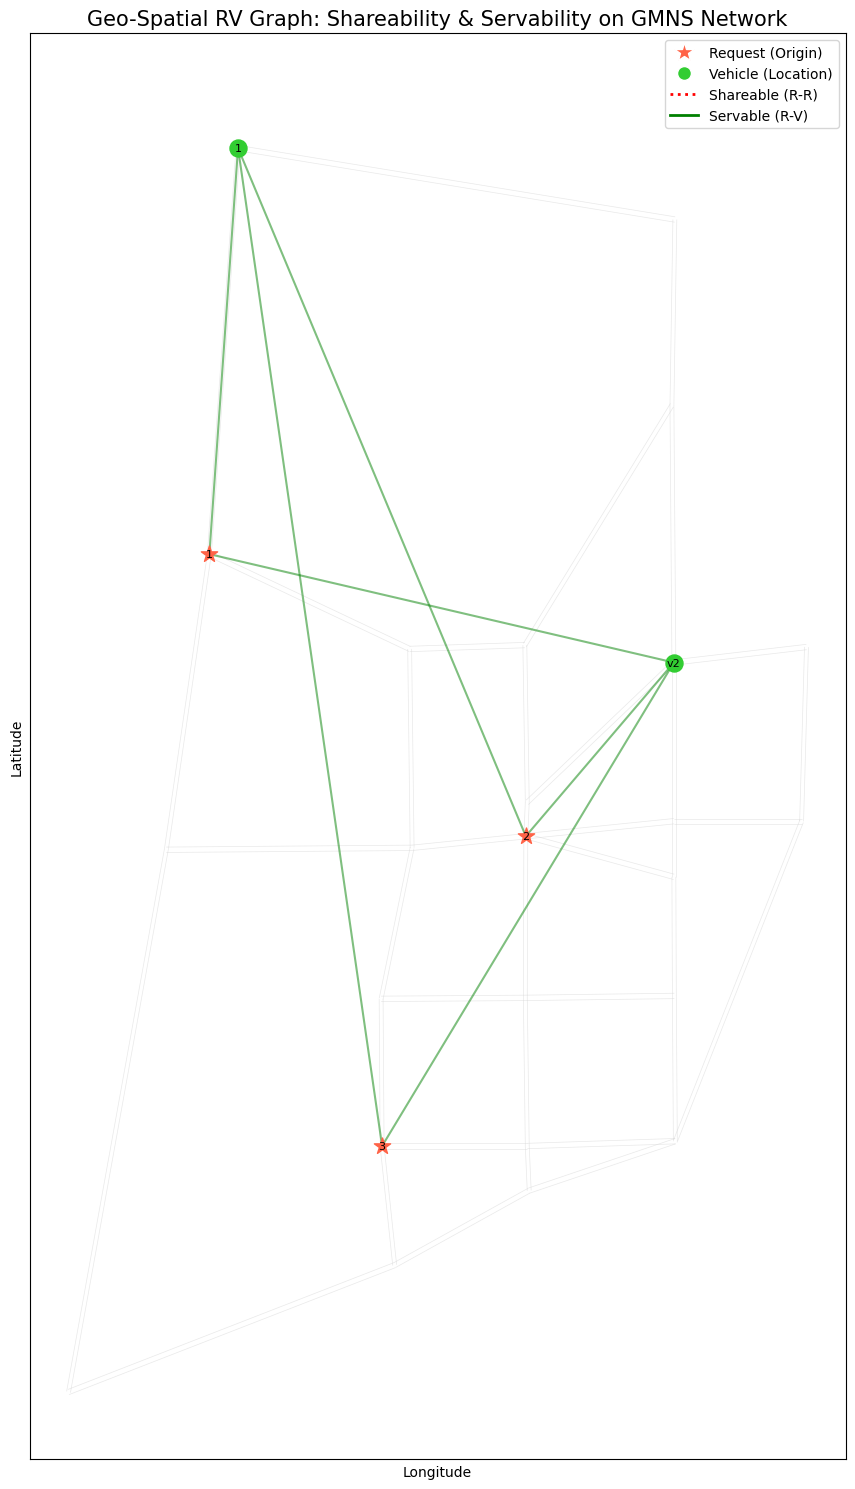

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd
from shapely.geometry import LineString

def visualize_rv_on_map(requests, vehicles, RV, TRIPS, node_df, link_gdf=None):
    """
    Visualizes the RV graph overlaying the actual GMNS street network.
    """

    # --- 1. Setup Coordinate Mapping ---
    # Create a dictionary to look up (x, y) coordinates for any node ID
    # structure: {node_id: (x_coord, y_coord)}
    node_coords = node_df.set_index('node_id')[['x_coord', 'y_coord']].to_dict('index')

    # Define positions for graph nodes based on their real-world location
    pos = {}

    # Requests are positioned at their Origin Node
    for r in requests:
        if r.origin in node_coords:
            coords = node_coords[r.origin]
            pos[r] = (coords['x_coord'], coords['y_coord'])

    # Vehicles are positioned at their Current Node (qv)
    for v in vehicles:
        if v.qv in node_coords:
            coords = node_coords[v.qv]
            pos[v] = (coords['x_coord'], coords['y_coord'])

    # --- 2. Build the Graph Structure ---
    G = nx.Graph()
    G.add_nodes_from(requests)
    G.add_nodes_from(vehicles)

    # Add Servability Edges (Green) - Vehicle to Request
    rv_edges = []
    for r, v in RV:
        if r in pos and v in pos: # Ensure both have valid coords
            rv_edges.append((r, v))

    # Add Shareability Edges (Red) - Request to Request
    rr_edges = set()
    for trip_requests in TRIPS.keys():
        if len(trip_requests) >= 2:
            import itertools
            for r1, r2 in itertools.combinations(trip_requests, 2):
                if r1 in pos and r2 in pos:
                    rr_edges.add((r1, r2))

    # --- 3. Plotting ---
    fig, ax = plt.subplots(figsize=(15, 15))

    # A. Draw the Background Map (Street Network)
    if link_gdf is not None:
        # If you have the geometry parsed from earlier steps
        link_gdf.plot(ax=ax, color='lightgray', linewidth=0.5, alpha=0.5, zorder=1)
    else:
        print("Warning: link_gdf not provided, skipping background map.")

    # B. Draw the Edges (Connections)
    # Shareability (Red Dotted)
    nx.draw_networkx_edges(G, pos, edgelist=list(rr_edges), ax=ax,
                           edge_color='red', style='dotted', width=2, alpha=0.6, label='Shareability')

    # Servability (Green Solid)
    nx.draw_networkx_edges(G, pos, edgelist=rv_edges, ax=ax,
                           edge_color='green', style='solid', width=1.5, alpha=0.5, label='Servability')

    # C. Draw the Nodes
    # Requests (Orange Stars)
    nx.draw_networkx_nodes(G, pos, nodelist=requests, ax=ax,
                           node_color='#FF6347', node_shape='*', node_size=150, label='Requests')

    # Vehicles (Green Circles)
    nx.draw_networkx_nodes(G, pos, nodelist=vehicles, ax=ax,
                           node_color='#32CD32', node_shape='o', node_size=150, label='Vehicles')

    # D. Labels (Optional - can be messy on a map)
    # Only label if there are few items, otherwise it overlaps too much
    if len(requests) + len(vehicles) < 50:
        labels = {node: getattr(node, 'id', str(node)) for node in G.nodes() if node in pos}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color='black', ax=ax)

    # Aesthetics
    plt.title("Geo-Spatial RV Graph: Shareability & Servability on GMNS Network", fontsize=15)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Create a custom legend manually because nx.draw handles legends poorly
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#FF6347', markersize=15, label='Request (Origin)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#32CD32', markersize=10, label='Vehicle (Location)'),
        Line2D([0], [0], color='red', linestyle=':', linewidth=2, label='Shareable (R-R)'),
        Line2D([0], [0], color='green', linestyle='-', linewidth=2, label='Servable (R-V)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

# --- Run Visualization ---
# Ensure link_gdf is available (from your Step 1 cell).
# If link_gdf is None, make sure you ran the cell that converts link.csv to geopandas.
visualize_rv_on_map(requests, vehicles, RV, TRIPS, node_df, link_gdf)

## Step 4.3: Greedy Assignment

In [24]:
def greedy_assignment(requests, vehicles, trips, trip_costs, trip_to_vehicle):
    """

    Parameters
    ----------
    requests : list of Request IDs (strings)
    vehicles : list of Vehicle IDs (strings)
    trips : dict
        key = trip_id (string)
        value = set of request IDs included in the trip
    trip_costs : dict
        key = (trip_id, vehicle_id)
        value = numeric cost for assigning that trip to that vehicle
    trip_to_vehicle : dict
        key = trip_id
        value = list of vehicle IDs that can serve it

    Returns
    -------
    Sigma : list of (trip_id, vehicle_id)
        Greedy feasible assignment.
    """

    # Track which requests/vehicles are already used
    assigned_requests = set()
    assigned_vehicles = set()

    # Final greedy assignment list
    Sigma = []

    # -----------------------------------------------
    # 1. Group trips by their size 1,2,3,...
    # -----------------------------------------------
    trips_by_size = {}
    for t_id, reqs in trips.items():
        k = len(reqs)
        if k not in trips_by_size:
            trips_by_size[k] = []
        trips_by_size[k].append(t_id)

    # -----------------------------------------------
    # 2. Process trip sizes from largest to smallest
    # -----------------------------------------------
    for k in sorted(trips_by_size.keys(), reverse=True):

        # List of all (trip_id, vehicle_id, cost) tuples
        trip_vehicle_pairs = []

        for t_id in trips_by_size[k]:
            for v_id in trip_to_vehicle[t_id]:
                if (t_id, v_id) in trip_costs:
                    cost = trip_costs[(t_id, v_id)]
                    trip_vehicle_pairs.append((t_id, v_id, cost))

        # Sort by increasing cost
        trip_vehicle_pairs.sort(key=lambda x: x[2])

        # -------------------------------------------
        # 3. Greedy selection
        # -------------------------------------------
        for t_id, v_id, cost in trip_vehicle_pairs:

            # Vehicle already assigned? Skip
            if v_id in assigned_vehicles:
                continue

            # Any request in this trip already assigned? Skip
            reqs = trips[t_id]
            if any(r in assigned_requests for r in reqs):
                continue

            # Otherwise: accept the trip-vehicle assignment
            Sigma.append((t_id, v_id))

            assigned_vehicles.add(v_id)
            assigned_requests.update(reqs)

    return Sigma


## Step 4.4: Optimal Assignment

In [25]:
import pulp

def optimal_assignment(requests, vehicles, trips, trip_costs, trip_to_vehicle, ignore_cost=9999):
    """
    Implements the ILP optimizer for trip-vehicle assignment
    exactly as defined in Algorithm 3 in PNAS (2017).

    Parameters
    ----------
    requests : list of request IDs (strings)
    vehicles : list of vehicle IDs (strings)
    trips : dict
        key = trip_id (string)
        value = set of request IDs in that trip
    trip_costs : dict
        key = (trip_id, vehicle_id)
        value = numeric cost of assigning trip to vehicle
    trip_to_vehicle : dict
        key = trip_id
        value = list of vehicles that can serve that trip
    ignore_cost : numeric
        cost of ignoring a request (paper uses a large constant)

    Returns
    -------
    Sigma_opt : list of (trip_id, vehicle_id)
    ignored_requests : list of request IDs
    """

    # ---------------------------------------
    # 1. Create the ILP model
    # ---------------------------------------
    model = pulp.LpProblem("OptimalAssignment", pulp.LpMinimize)

    # -------------------------------------------------------------
    # 2. Decision variables
    # ε_(i,j) = 1 if vehicle j is assigned to trip i
    # χ_k = 1 if request k is ignored
    # -------------------------------------------------------------
    epsilon = {}
    for t_id in trips:
        for v_id in trip_to_vehicle[t_id]:
            if (t_id, v_id) in trip_costs:
                var_name = f"eps_{t_id}_{v_id}"
                epsilon[(t_id, v_id)] = pulp.LpVariable(var_name, 0, 1, pulp.LpBinary)

    chi = {}
    for r_id in requests:
        chi[r_id] = pulp.LpVariable(f"chi_{r_id}", 0, 1, pulp.LpBinary)

    # -------------------------------------------------------------
    # 3. Objective: minimize sum(cost_t_v * eps_t_v) + sum(ignore_cost * chi_r)
    # -------------------------------------------------------------
    model += (
        pulp.lpSum(trip_costs[(t_id, v_id)] * epsilon[(t_id, v_id)]
                   for (t_id, v_id) in epsilon)
        +
        pulp.lpSum(ignore_cost * chi[r_id] for r_id in requests)
    )

    # -------------------------------------------------------------
    # 4. Constraints
    # -------------------------------------------------------------

    # 4a. Vehicle constraint: each vehicle assigned at most one trip
    # Σ_i ε_(i,j) ≤ 1
    for v_id in vehicles:
        model += (
            pulp.lpSum(epsilon[(t_id, v_id)]
                       for (t_id, vv) in epsilon if vv == v_id) <= 1
        )

    # 4b. Request constraint: each request served once or ignored
    # Σ_i Σ_j∈IT_i ε_(i,j) + χ_k = 1
    for r_id in requests:
        involved_epsilon = []
        for (t_id, v_id) in epsilon:
            if r_id in trips[t_id]:
                involved_epsilon.append(epsilon[(t_id, v_id)])

        model += (
            pulp.lpSum(involved_epsilon) + chi[r_id] == 1
        )

    # -------------------------------------------------------------
    # 5. Solve the ILP
    # -------------------------------------------------------------
    model.solve(pulp.PULP_CBC_CMD(msg=False))

    # -------------------------------------------------------------
    # 6. Extract solution
    # -------------------------------------------------------------
    Sigma_opt = []
    ignored_requests = []

    for (t_id, v_id), var in epsilon.items():
        if var.value() == 1:
            Sigma_opt.append((t_id, v_id))

    for r_id, var in chi.items():
        if var.value() == 1:
            ignored_requests.append(r_id)

    return Sigma_opt, ignored_requests


# Step 5: Run the Full Algorithm

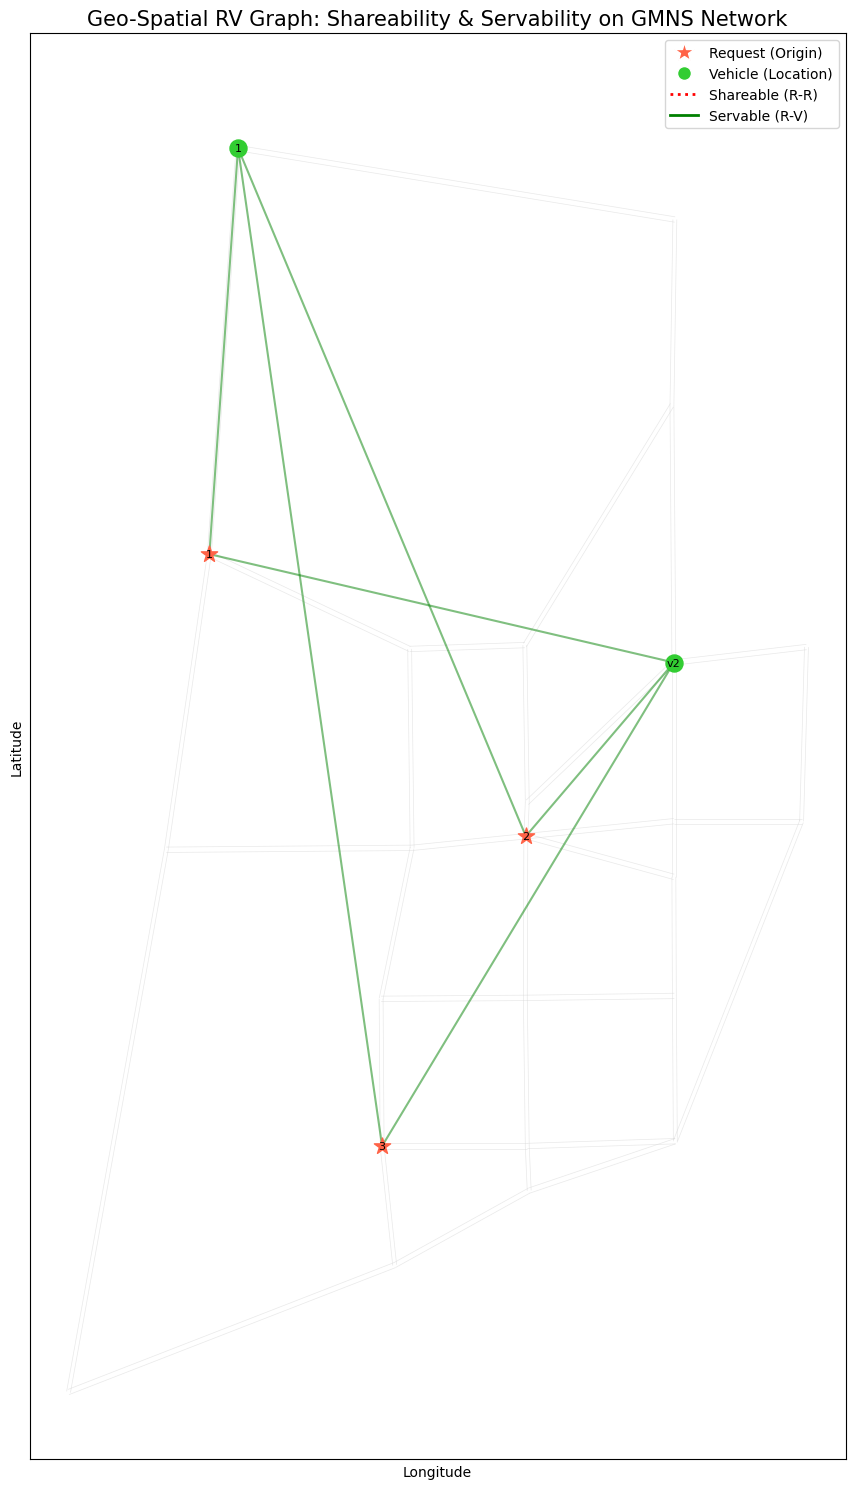

Optimal Assignment:
   T[1] → V1
   T[2,3] → Vv2

Ignored Requests: []
Ignored Requests: []


In [27]:
import networkx as nx

r1 = Request(
    origin=3,
    destination=15,
    request_time=0,
    latest_pickup=300,
    earliest_arrival=shortest_path(3, 15, link_df),
    id = 1
)

r2 = Request(
    origin=10,
    destination=22,
    request_time=20,
    latest_pickup=260,
    earliest_arrival=shortest_path(10, 22, link_df),
    id = 2
)

r3 = Request(
    origin=23,
    destination = 12,
    request_time = 5,
    latest_pickup = 200,
    earliest_arrival = shortest_path(23, 12, link_df),
    id = 3
)

requests = [r1, r2, r3]

v1 = Vehicle(
    start_node=1,
    start_time=0,
    onboard=[],
    id = 1
)

v2 = Vehicle(start_node=8, start_time=0, onboard=[], id=2)

vehicles = [v1, v2]

RV = set()

for r in requests:
    for v in vehicles:
        if travel(v, {r}) is not None:
            RV.add((r, v))
RTV = nx.DiGraph()

visualize_rv_on_map(requests, vehicles, RV, TRIPS, node_df, link_gdf)

trips = build_trips(requests, vehicles, RV, max_capacity=4)

trip_to_vehicle = {}

for tkey, reqset in trips.items():
    trip_to_vehicle[tkey] = []

    for v in vehicles:
        # If travel() returns a cost, vehicle can serve this trip
        cost = travel(v, reqset)
        if cost is not None:
            trip_to_vehicle[tkey].append(v)

trip_costs = {}

for tkey, reqset in trips.items():
    for v in trip_to_vehicle[tkey]:
        cost = travel(v, reqset)
        trip_costs[(tkey, v)] = cost

Sigma_opt, ignored = optimal_assignment(
    requests,
    vehicles,
    trips,
    trip_costs,
    trip_to_vehicle,
    ignore_cost=9999
)

print("Optimal Assignment:")
for tset, v in Sigma_opt:
    print("  ", trip_name(tset), "→", v)

print("\nIgnored Requests:", [r.id for r in ignored])